**Latar Belakang**

Pertumbuhan konten berita digital yang sangat masif membuat pengelompokan otomatis menjadi kebutuhan penting. Dengan banyaknya artikel yang diterbitkan setiap harinya, sistem klasifikasi dokumen dapat membantu menyusun berita berdasarkan topik seperti politik, olahraga, hiburan, bisnis, dan teknologi.

Salah satu pendekatan terkini yang memberikan hasil luar biasa dalam pemrosesan bahasa alami adalah **BERT (Bidirectional Encoder Representations from Transformers)**. BERT merupakan model pre-trained dari Google yang dirancang untuk memahami konteks kalimat secara dua arah (kiri dan kanan) sekaligus. Dengan pendekatan ini, BERT mampu memberikan representasi kontekstual yang lebih akurat dibanding model tradisional seperti TF-IDF atau Word2Vec.

Model ini dapat digunakan untuk berbagai tugas NLP, termasuk klasifikasi dokumen, dengan cara melakukan fine-tuning terhadap layer akhir dari model pre-trained menggunakan dataset spesifik.


**Dataset**

Dataset yang digunakan berasal dari **[BBC Full-Text Document Classification](https://www.kaggle.com/datasets/shivamkushwaha/bbc-full-text-document-classification)**. Dataset ini terdiri dari artikel berita asli BBC yang dikategorikan ke dalam lima topik utama:
- **Business**
- **Entertainment**
- **Politics**
- **Sport**
- **Tech**

Tugas yang dilakukan adalah memprediksi kategori/topik dari suatu artikel berita berdasarkan konten teks secara keseluruhan. Hal ini merupakan permasalahan **multi-class classification**.

Dataset diproses dengan cara membaca seluruh file berita berdasarkan folder (label), lalu dilakukan:
- Ekstraksi `title` dan `body`
- Gabungkan sebagai `text`
- Label diambil dari nama folder (kategori berita)
- Dibentuk ke dalam DataFrame dengan dua kolom utama: `text` dan `label`


**Variabel yang Digunakan**

| Nama Variabel | Tipe Data | Deskripsi                                                                 |
|---------------|-----------|---------------------------------------------------------------------------|
| `text`        | string    | Gabungan dari judul (`title`) dan isi artikel (`body`) berita BBC         |
| `label`       | string    | Kategori/topik berita seperti: business, politics, sport, dsb             |
| `label_id`    | integer   | Label numerik hasil encoding dari kategori teks (`label`)                 |
| `text_split`  | list      | List dari potongan teks (≤ 200 token) yang disiapkan untuk input ke BERT  |
| `train_df`    | DataFrame | Dataset untuk pelatihan model BERT                                        |
| `val_df`      | DataFrame | Dataset untuk validasi model BERT                                         |


**Setup Environment dan Instalasi**

Notebook ini menggunakan:
- **TensorFlow 1.15**, karena versi `run_classifier.py` dan `modeling.py` masih berbasis pada TensorFlow 1.x
- File fungsi BERT diunduh langsung dari repository [google-research/bert](https://github.com/google-research/bert), termasuk:
  - `modeling.py`: struktur arsitektur BERT
  - `optimization.py`: pengaturan optimisasi model
  - `run_classifier.py`: fungsi utility klasifikasi
  - `tokenization.py`: tokenizer BERT berbasis WordPiece


In [ ]:
!pip uninstall tensorflow -y
!pip install tensorflow==1.15

Getting bert functions

In [ ]:
!wget https://raw.githubusercontent.com/google-research/bert/master/modeling.py
!wget https://raw.githubusercontent.com/google-research/bert/master/optimization.py
!wget https://raw.githubusercontent.com/google-research/bert/master/run_classifier.py
!wget https://raw.githubusercontent.com/google-research/bert/master/tokenization.py

**Library yang Digunakan**

| Library | Keterangan |
|---------|------------|
| `tensorflow` | Digunakan versi 1.15 agar kompatibel dengan kode BERT |
| `tensorflow_hub` | Untuk memuat pre-trained BERT dari TensorFlow Hub |
| `sklearn` | Untuk encoding label dan train-test split |
| `nltk` | Untuk preprocessing seperti stopwords |
| `datetime` | Untuk mencatat durasi waktu eksekusi |
| `re`, `os` | Untuk eksplorasi file/folder dan pembersihan karakter |

In [ ]:
import numpy as np # linear algebra
import re, os
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import tensorflow as tf

import datetime
from datetime import datetime

# BERT
import optimization
import run_classifier
import tokenization
import tensorflow_hub as hub

In [ ]:
# Checking tensorflow version (should be 1.15)
tf.__version__

'1.15.0'

**Proses Load Dataset**

Dataset BBC terdiri dari file teks yang dikelompokkan dalam folder berdasarkan kategori:
- `business/`
- `politics/`
- `sport/`
- `entertainment/`
- `tech/`

Langkah yang dilakukan:
1. Looping seluruh subfolder untuk mengambil:
   - `label` dari nama folder
   - `title` dari baris pertama
   - `body` dari isi baris selanjutnya
2. Semua data digabung dalam list dan disimpan sebagai variabel:
   - `directory`: path folder
   - `file`: nama file
   - `title`: baris pertama dari file
   - `text`: seluruh isi teks (gabungan)
   - `label`: kategori topik berita

In [ ]:
# Get the file details
directory = []
file = []
title = []
text = []
label = []
datapath = '../input/bbc-full-text-document-classification/bbc-fulltext (document classification)/bbc/'
for dirname, _ , filenames in os.walk(datapath):
    #print('Directory: ', dirname)
    #print('Subdir: ', dirname.split('/')[-1])
    # remove the Readme.txt file
    # will not find file in the second iteration so we skip the error
    try:
        filenames.remove('README.TXT')
    except:
        pass
    for filename in filenames:
        directory.append(dirname)
        file.append(filename)
        label.append(dirname.split('/')[-1])
        fullpathfile = os.path.join(dirname,filename)
        with open(fullpathfile, 'r', encoding="utf8", errors='ignore') as infile:
            intext = ''
            firstline = True
            for line in infile:
                if firstline:
                    title.append(line.replace('\n',''))
                    firstline = False
                else:
                    intext = intext + ' ' + line.replace('\n','')
            text.append(intext)


**Konversi Data ke Bentuk DataFrame**

Setelah data berhasil diekstrak dari folder berdasarkan label (nama folder), data dikonversi menjadi bentuk DataFrame `pandas`. Kolom-kolom awal mencakup:
- `directory` → direktori tempat file berada
- `file` → nama file
- `title` → baris pertama dari file, digunakan sebagai judul
- `text` → isi lengkap artikel
- `label` → topik atau kategori berita (business, sport, dll.)

Namun, untuk analisis dan modeling, hanya kolom `text` dan `label` yang digunakan, sehingga dibuat DataFrame baru bernama `df`.


In [ ]:
DATA_COLUMN = 'text'
LABEL_COLUMN = 'label'

fulldf = pd.DataFrame(list(zip(directory, file, title, text, label)),
               columns =['directory', 'file', 'title', 'text', 'label'])

df = fulldf.filter(['text','label'], axis=1)
df.head()

,text,label
0,Gordon Brown will seek to put the economy at...,politics
1,Military chiefs are expected to meet to make...,politics
2,Michael Howard has denied his shadow cabinet...,politics
3,Ministers will invite international observer...,politics
4,Ex-chat show host Robert Kilroy-Silk is to c...,politics


**Jumlah Data dan Pengecekan Null**

Checking the shape of the dataframe

In [ ]:
df.shape

(2225, 2)

Checking if null values exist

In [ ]:
df.isnull().sum()

text     0
label    0
dtype: int64

Dataset memiliki:
- **2225 baris**
- **2 kolom utama**: `text` dan `label`
- **Tidak ditemukan missing values** pada kedua kolom tersebut, sehingga data siap diproses tanpa pembersihan lanjutan.


**Distribusi Label (Kategori Berita)**

In [ ]:
for label in np.unique(df['label']):
    print(label)

business
entertainment
politics
sport
tech


Terdapat 5 kategori berita utama:
- `sport`
- `business`
- `politics`
- `tech`
- `entertainment`

Distribusi jumlah data cukup seimbang:
- Kategori **sport** dan **business** mendominasi,
- Sedangkan **entertainment** memiliki jumlah artikel paling sedikit.

Visualisasi menggunakan bar chart digunakan untuk memeriksa sebaran ini, yang penting untuk menghindari bias pada model klasifikasi nantinya.


<AxesSubplot:>

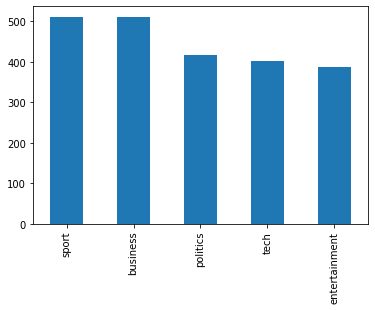

In [ ]:
# Checking number of records of each label
df['label'].value_counts().sort_values(ascending=False).plot(kind='bar')

**Encode the Labels into Numeric**

Label pada dataset awal masih berupa string kategori seperti:
- `business`
- `entertainment`
- `politics`
- `sport`
- `tech`

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
df.head()

,text,label
0,Gordon Brown will seek to put the economy at...,2
1,Military chiefs are expected to meet to make...,2
2,Michael Howard has denied his shadow cabinet...,2
3,Ministers will invite international observer...,2
4,Ex-chat show host Robert Kilroy-Silk is to c...,2


Agar dapat digunakan oleh algoritma machine learning, label tersebut dikonversi ke format numerik menggunakan `LabelEncoder`. Hasil encoding akan mengubah:
- `business` → 0
- `entertainment` → 1
- `politics` → 2
- dan seterusnya.


**Preprocessing ke Teks**

Teks dari masing-masing artikel kemudian dibersihkan melalui beberapa tahapan preprocessing, yaitu:

1. **Lowercasing**  
   Mengubah seluruh huruf menjadi huruf kecil agar tidak dianggap berbeda oleh model.

2. **Menghapus simbol**  
   Menggunakan regex `REPLACE_BY_SPACE_RE` dan `BAD_SYMBOLS_RE` untuk menghapus simbol-simbol yang tidak diperlukan seperti: `@`, `#`, `{}`, angka, tanda baca, dll.

3. **Menghapus Stopwords**  
   Menghapus kata-kata umum dalam Bahasa Inggris seperti "the", "is", "and", dll. yang tidak memberikan banyak informasi untuk klasifikasi.

4. **Optional: Menghapus angka**  
   Ditambahkan juga pembersihan angka dengan `str.replace('\d+', '')`.


In [ ]:
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """
        text: a string

        return: modified initial string
    """
    text = text.lower() # lowercase text
    text = REPLACE_BY_SPACE_RE.sub(' ', text) # replace REPLACE_BY_SPACE_RE symbols by space in text. substitute the matched string in REPLACE_BY_SPACE_RE with space.
    text = BAD_SYMBOLS_RE.sub('', text) # remove symbols which are in BAD_SYMBOLS_RE from text. substitute the matched string in BAD_SYMBOLS_RE with nothing.
#     text = re.sub(r'\W+', '', text)
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # remove stopwors from text
    return text

In [ ]:
df['text'] = df['text'].apply(clean_text)
df['text'] = df['text'].str.replace('\d+', '')
df.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  


,text,label
0,gordon brown seek put economy centre labours b...,2
1,military chiefs expected meet make final decis...,2
2,michael howard denied shadow cabinet split dec...,2
3,ministers invite international observers check...,2
4,exchat show host robert kilroysilk contest der...,2


**Preprocessing Tambahan untuk BERT**

Model BERT memiliki batas panjang input (sekitar 512 token), sehingga untuk menghindari potongan teks yang terlalu panjang:
- Teks yang panjangnya melebihi batas akan dipecah menjadi beberapa bagian sepanjang 200 kata per bagian.
- Fungsi `get_split()` digunakan untuk membagi teks menjadi potongan-potongan yang sesuai agar tidak melebihi batas input BERT.

Langkah ini penting untuk memastikan tidak ada informasi yang hilang saat model menerima input teks.



In [ ]:
def get_split(text1):
    l_total = []
    l_parcial = []
    if len(text1.split())//150 >0:
        n = len(text1.split())//150
    else:
        n = 1
    for w in range(n):
        if w == 0:
            l_parcial = text1.split()[:200]
            l_total.append(" ".join(l_parcial))
        else:
            l_parcial = text1.split()[w*150:w*150 + 200]
            l_total.append(" ".join(l_parcial))
    return l_total

In [ ]:
df['text_split'] = df['text'].apply(get_split)
df.head()

,text,label,text_split
0,gordon brown seek put economy centre labours b...,2,[gordon brown seek put economy centre labours ...
1,military chiefs expected meet make final decis...,2,[military chiefs expected meet make final deci...
2,michael howard denied shadow cabinet split dec...,2,[michael howard denied shadow cabinet split de...
3,ministers invite international observers check...,2,[ministers invite international observers chec...
4,exchat show host robert kilroysilk contest der...,2,[exchat show host robert kilroysilk contest de...


**Pengaturan Direktori Output untuk BERT**

* Direktori output ditentukan melalui variabel `OUTPUT_DIR`, yang dalam kasus ini diset ke `'/bert_news_category'`.
* Parameter `DO_DELETE = True` digunakan untuk menghapus direktori tersebut terlebih dahulu jika sudah ada sebelumnya, agar tidak terjadi konflik atau kesalahan saat menyimpan model baru.
* Setelah pengecekan dan penghapusan, direktori baru dibuat untuk menyimpan hasil pelatihan model BERT.


In [ ]:
# Set the output directory for saving model file
OUTPUT_DIR = '/bert_news_category'

#@markdown Whether or not to clear/delete the directory and create a new one
DO_DELETE = True #@param {type:"boolean"}

if DO_DELETE:
    try:
        tf.gfile.DeleteRecursively(OUTPUT_DIR)
#         tf.compat.v1.gfile.DeleteRecursively(OUTPUT_DIR)
    except:
        pass

tf.gfile.MakeDirs(OUTPUT_DIR)
print('***** Model output directory: {} *****'.format(OUTPUT_DIR))

***** Model output directory: /bert_news_category *****


**Split Data Menjadi Training dan Validation**

* Data dibagi menggunakan fungsi `train_test_split()` menjadi:
  * 80% untuk data pelatihan (`train`)
  * 20% untuk data validasi (`val`)
* Parameter `random_state=35` digunakan agar pembagian data tetap konsisten di setiap eksekusi.
* Index dataframe di-reset agar lebih rapi dan siap diproses lebih lanjut.

In [ ]:
train, val = train_test_split(df, test_size=0.2, random_state=35)
train.reset_index(drop=True, inplace=True)
train.head(2)

,text,label,text_split
0,fox hunting dogs illegal england wales ban act...,2,[fox hunting dogs illegal england wales ban ac...
1,top seeds south africa return scene one embarr...,3,[top seeds south africa return scene one embar...


**Cek Label Unik**

* Dilakukan pengecekan terhadap label unik dengan `np.unique(df['label'])`.
* Hasilnya menunjukkan 5 kategori:
  * `0`, `1`, `2`, `3`, `4`
* Label ini sesuai dengan hasil encoding sebelumnya dari kategori:
  * `business`, `entertainment`, `politics`, `sport`, `tech`

In [ ]:
# Get labels
label_list = [x for x in np.unique(train.label)]
label_list

[0, 1, 2, 3, 4]

In [ ]:
val.reset_index(drop=True, inplace=True)
val.head(2)

,text,label,text_split
0,listen full interview sport five bbc sport web...,3,[listen full interview sport five bbc sport we...
1,ronan ogara scored irelands points home side c...,3,[ronan ogara scored irelands points home side ...


**Cek Ukuran Dataset**

* Dataset training berukuran `(1780, 3)` dan validation `(445, 3)`.
* Tiga kolom yang digunakan: `text`, `label`, dan `text_split`.

In [ ]:
val.shape, train.shape

((445, 3), (1780, 3))

**Persiapan Struktur Data untuk Model**

* Dataset di-flatten berdasarkan jumlah potongan teks di `text_split`.
* Setiap potongan teks dihitung sebagai satu entri untuk pelatihan model.
* Hasil akhir:
  * Jumlah potongan untuk training: 2176
  * Jumlah potongan untuk validation: 538

In [ ]:
train_l = []
label_l = []
index_l =[]
for idx,row in train.iterrows():
    for l in row['text_split']:
        train_l.append(l)
        label_l.append(row['label'])
        index_l.append(idx)
len(train_l), len(label_l), len(index_l)

(2176, 2176, 2176)

 Ada 2176 potongan teks, 2176 label, dan 2176 indeks, menandakan bahwa data telah diproses dengan benar.

In [ ]:
val_l = []
val_label_l = []
val_index_l = []
for idx,row in val.iterrows():
    for l in row['text_split']:
        val_l.append(l)
        val_label_l.append(row['label'])
        val_index_l.append(idx)
len(val_l), len(val_label_l), len(val_index_l)

(538, 538, 538)

Ada 538 potongan teks, 538 label, dan 538 indeks, menandakan bahwa data telah diproses dengan benar.

**Mempersiapkan Data Training dan Validasi sebagai DataFrame**
* Data training dan validasi yang sebelumnya diproses dan dipecah menjadi potongan teks (text_split) kini dikonversi kembali ke dalam format DataFrame.
* Masing-masing DataFrame (train_df dan val_df) memuat kolom teks (text) dan label (label) untuk keperluan input ke model BERT.
* Langkah ini memudahkan pengelolaan data sebelum masuk ke tahap pembuatan objek InputExample dan fine-tuning model.

In [ ]:
train_df = pd.DataFrame({DATA_COLUMN:train_l, LABEL_COLUMN:label_l})
train_df.head()

,text,label
0,fox hunting dogs illegal england wales ban act...,2
1,top seeds south africa return scene one embarr...,3
2,teenagers able become mps plans unveiled minis...,2
3,price gold fallen international monetary fund ...,0
4,manchester united reduced chelseas premiership...,3


In [ ]:
val_df = pd.DataFrame({DATA_COLUMN:val_l, LABEL_COLUMN:val_label_l})
val_df.head()

,text,label
0,listen full interview sport five bbc sport web...,3
1,season parry said sincerely hope steven knows ...,3
2,complete naming rights given anfield club seri...,3
3,discussions steve course think came close conc...,3
4,ronan ogara scored irelands points home side c...,3


In [ ]:
# X_train, X_val, y_train, y_val = train_test_split(df['text'], df['label'], test_size=0.20, random_state=42)

**Fine-tuning the BERT Model**

**1. Mempersiapkan Data Input dengan `InputExample` dari BERT**

* **Pembuatan `InputExample` untuk Data Pelatihan dan Validasi**:
    - Dalam tahap ini, data teks dari dataset pelatihan dan validasi diubah menjadi objek `InputExample` menggunakan `run_classifier.InputExample`.
    - `text_a` berisi teks artikel berita yang akan diklasifikasikan, sementara `label` merujuk pada kategori atau label yang sesuai (misalnya, politik, bisnis, dll.).
    - Setiap artikel teks diberi ID unik yang digunakan oleh BERT saat melatih model.


In [ ]:
# Use the InputExample class from BERT's run_classifier code to create examples from the data
train_InputExamples = train.apply(lambda x: run_classifier.InputExample(guid=None, # Globally unique ID for bookkeeping, unused in this example
                                                                   text_a = x[DATA_COLUMN],
                                                                   text_b = None,
                                                                   label = x[LABEL_COLUMN]), axis = 1)

val_InputExamples = val.apply(lambda x: run_classifier.InputExample(guid=None,
                                                                   text_a = x[DATA_COLUMN],
                                                                   text_b = None,
                                                                   label = x[LABEL_COLUMN]), axis = 1)

In [ ]:
train_InputExamples

0       <run_classifier.InputExample object at 0x7f17b...
1       <run_classifier.InputExample object at 0x7f17b...
2       <run_classifier.InputExample object at 0x7f17b...
3       <run_classifier.InputExample object at 0x7f17b...
4       <run_classifier.InputExample object at 0x7f17b...
                              ...                        
1775    <run_classifier.InputExample object at 0x7f17b...
1776    <run_classifier.InputExample object at 0x7f17b...
1777    <run_classifier.InputExample object at 0x7f17b...
1778    <run_classifier.InputExample object at 0x7f17b...
1779    <run_classifier.InputExample object at 0x7f17b...
Length: 1780, dtype: object

In [ ]:
print("Row 0 - guid of training set : ", train_InputExamples.iloc[0].guid)
print("\n__________\nRow 0 - text_a of training set : ", train_InputExamples.iloc[0].text_a)
print("\n__________\nRow 0 - text_b of training set : ", train_InputExamples.iloc[0].text_b)
print("\n__________\nRow 0 - label of training set : ", train_InputExamples.iloc[0].label)

Row 0 - guid of training set :  None

__________
Row 0 - text_a of training set :  fox hunting dogs illegal england wales ban activity came force overnight law faces stiff test weekend countryside alliance saying many hunts force chief police officers spokesman nigel yeo said expected people would obey law drag hunting chasing foxes shooting said police would challenge one two isolated hunts threatening break law simon hart countryside alliance questioned police ensure violations definitions legal illegal hunting blurred police asked make impossible judgements hunt rat mouse rabbit hare artificial scent real one said attorney general lord goldsmith far issued instructions police deal hunters violate law said consult director public prosecutions police near future decide measures take regards hunting prosecutions rejected blanket policy enforcing ban house lords considered legality john cooper barrister chairman league cruel sports said antihunting lobby expects authorities prosecute wh

**Tokenisasi Teks**

Tokenisasi Teks dengan BERT Tokenizer:

* Setelah mengonversi data ke dalam format InputExample, tahap selanjutnya adalah mempersiapkan data agar dapat diterima oleh model BERT.

*Fungsi create_tokenizer_from_hub_module() digunakan untuk mendapatkan tokenizer dari TensorFlow Hub yang dapat memecah kalimat menjadi token-token yang lebih kecil.

* Jumlah token dalam model ini dapat diproses lebih lanjut oleh BERT. Tokenizer ini mengonversi teks artikel ke dalam format token, yang digunakan untuk memberi representasi numerik bagi model.

In [ ]:
BERT_MODEL_HUB = "https://tfhub.dev/google/bert_uncased_L-12_H-768_A-12/1"

def create_tokenizer_from_hub_module():
  """Get the vocab file and casing info from the Hub module."""
  with tf.Graph().as_default():
    bert_module = hub.Module(BERT_MODEL_HUB)
    tokenization_info = bert_module(signature="tokenization_info", as_dict=True)
    with tf.Session() as sess:
#     with tf.compat.v1.Session() as sess:
        vocab_file, do_lower_case = sess.run([tokenization_info["vocab_file"],
                                            tokenization_info["do_lower_case"]])

    return tokenization.FullTokenizer(
      vocab_file=vocab_file, do_lower_case=do_lower_case)

tokenizer = create_tokenizer_from_hub_module()

2022-02-22 11:42:23.771865: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/conda/lib
2022-02-22 11:42:23.772234: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: UNKNOWN ERROR (303)
2022-02-22 11:42:23.772285: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (a2bc89e8fb7a): /proc/driver/nvidia/version does not exist
2022-02-22 11:42:23.785384: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2022-02-22 11:42:23.822541: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2200145000 Hz
2022-02-22 11:42:23.823467: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5576872eb420 initialized for platform 

In [ ]:
len(tokenizer.vocab.keys())

30522

Setiap model BERT memiliki daftar kata (vocabulary) yang digunakan untuk memahami dan mengonversi teks menjadi token. Dalam hal ini, 30522 adalah jumlah total kata yang dapat diproses oleh tokenizer BERT. Artinya, BERT mengenali dan dapat mengonversi teks menjadi token sebanyak 30,522 token unik

**Tokenisasi Contoh Data Pertama**

Berikut adalah contoh bagaimana artikel pertama dalam dataset di-tokenize oleh tokenizer BERT.

Teks yang sebelumnya adalah "fox hunting dogs illegal england wales ban activity came force overnight law faces stiff test weekend countryside alliance saying magistrates court"


In [ ]:
#Here is what the tokenised sample of the first training set observation looks like
print(tokenizer.tokenize(train_InputExamples.iloc[0].text_a))

['fox', 'hunting', 'dogs', 'illegal', 'england', 'wales', 'ban', 'activity', 'came', 'force', 'overnight', 'law', 'faces', 'stiff', 'test', 'weekend', 'countryside', 'alliance', 'saying', 'many', 'hunts', 'force', 'chief', 'police', 'officers', 'spokesman', 'nigel', 'ye', '##o', 'said', 'expected', 'people', 'would', 'obey', 'law', 'drag', 'hunting', 'chasing', 'foxes', 'shooting', 'said', 'police', 'would', 'challenge', 'one', 'two', 'isolated', 'hunts', 'threatening', 'break', 'law', 'simon', 'hart', 'countryside', 'alliance', 'questioned', 'police', 'ensure', 'violations', 'definitions', 'legal', 'illegal', 'hunting', 'blurred', 'police', 'asked', 'make', 'impossible', 'judgement', '##s', 'hunt', 'rat', 'mouse', 'rabbit', 'hare', 'artificial', 'scent', 'real', 'one', 'said', 'attorney', 'general', 'lord', 'goldsmith', 'far', 'issued', 'instructions', 'police', 'deal', 'hunters', 'violate', 'law', 'said', 'consult', 'director', 'public', 'prosecution', '##s', 'police', 'near', 'futur

**2. Mengonversi Fitur Training dan Validasi menjadi InputFeatures yang Dipahami BERT**

* **Proses Pengubahan Fitur Menjadi Input yang Dipahami BERT**:
    - Fungsi `convert_examples_to_features` digunakan untuk mengonversi data dari format `InputExample` yang telah dibuat sebelumnya ke dalam format yang dapat dipahami oleh BERT.
    - Setiap artikel teks dipecah menjadi token dan diubah menjadi `input_ids`, `input_mask`, dan `segment_ids`.
    - **`MAX_SEQ_LENGTH`** diatur ke 200 untuk memastikan panjang teks yang diproses tidak melebihi batas maksimum yang bisa diterima oleh model BERT.
  

In [ ]:
MAX_SEQ_LENGTH = 200

train_features = run_classifier.convert_examples_to_features(train_InputExamples, label_list, MAX_SEQ_LENGTH, tokenizer)
val_features = run_classifier.convert_examples_to_features(val_InputExamples, label_list, MAX_SEQ_LENGTH, tokenizer)

In [ ]:
#Example on first observation in the training set
print("Sentence : ", train_InputExamples.iloc[0].text_a)
print("-"*30)
print("Tokens : ", tokenizer.tokenize(train_InputExamples.iloc[0].text_a))
print("-"*30)
print("Input IDs : ", train_features[0].input_ids)
print("-"*30)
print("Input Masks : ", train_features[0].input_mask)
print("-"*30)
print("Segment IDs : ", train_features[0].segment_ids)

Sentence :  fox hunting dogs illegal england wales ban activity came force overnight law faces stiff test weekend countryside alliance saying many hunts force chief police officers spokesman nigel yeo said expected people would obey law drag hunting chasing foxes shooting said police would challenge one two isolated hunts threatening break law simon hart countryside alliance questioned police ensure violations definitions legal illegal hunting blurred police asked make impossible judgements hunt rat mouse rabbit hare artificial scent real one said attorney general lord goldsmith far issued instructions police deal hunters violate law said consult director public prosecutions police near future decide measures take regards hunting prosecutions rejected blanket policy enforcing ban house lords considered legality john cooper barrister chairman league cruel sports said antihunting lobby expects authorities prosecute wherever clear evidence illegal hunting practices said police acknowledge

**Fungsi untuk Membuat Model Prediksi**


Fungsi create_model:

* Fungsi ini mengonfigurasi arsitektur model BERT untuk tugas klasifikasi. Model ini mengambil input berupa input_ids, input_mask, dan segment_ids.

* Output utama dari model ini adalah pooled_output, yang merupakan representasi keseluruhan kalimat setelah pemrosesan oleh BERT.

* Dropout diterapkan pada output layer untuk mencegah overfitting.

In [ ]:
def create_model(is_predicting, input_ids, input_mask, segment_ids, labels,
                 num_labels):
    """
    Create models for prediction using BERT.
    """
    bert_module = hub.Module(
        BERT_MODEL_HUB,
        trainable=True)
    bert_inputs = dict(
      input_ids=input_ids,
      input_mask=input_mask,
      segment_ids=segment_ids)
    bert_outputs = bert_module(
      inputs=bert_inputs,
      signature="tokens",
      as_dict=True)

    # Use "pooled_output" for classification tasks on an entire sentence.
    # Use "sequence_outputs" for token-level output.
    output_layer = bert_outputs["pooled_output"]
    # with tf.Session() as sess:
    output_layer1 = bert_outputs["pooled_output"]
    # output_layer1 = 999
    hidden_size = output_layer.shape[-1].value

    # Create our own layer to tune for politeness data.
    output_weights = tf.get_variable(
      "output_weights", [num_labels, hidden_size],
      initializer=tf.truncated_normal_initializer(stddev=0.02))

    output_bias = tf.get_variable(
      "output_bias", [num_labels], initializer=tf.zeros_initializer())

    with tf.variable_scope("loss"):

        # Dropout helps prevent overfitting
        output_layer = tf.nn.dropout(output_layer, keep_prob=0.8)

        logits = tf.matmul(output_layer, output_weights, transpose_b=True)
        logits = tf.nn.bias_add(logits, output_bias)
        log_probs = tf.nn.log_softmax(logits, axis=-1)

        # Convert labels into one-hot encoding
        one_hot_labels = tf.one_hot(labels, depth=num_labels, dtype=tf.float32)

        predicted_labels = tf.squeeze(tf.argmax(log_probs, axis=-1, output_type=tf.int32))
        # If we're predicting, we want predicted labels and the probabiltiies.
        if is_predicting:
            return (predicted_labels, log_probs, output_layer1)

        # If we're train/eval, compute loss between predicted and actual label
        per_example_loss = -tf.reduce_sum(one_hot_labels * log_probs, axis=-1)
        loss = tf.reduce_mean(per_example_loss)

        return (loss, predicted_labels, log_probs)

Fungsi model_fn_builder:

* Fungsi ini membangun model untuk estimator BERT yang dapat digunakan untuk pelatihan dan evaluasi. Ia juga mengatur proses optimasi dan perhitungan metrik evaluasi (seperti akurasi, true positives, dll.).

* Ketika mode adalah TRAIN, model akan mengoptimalkan loss dan melatih model. Jika mode adalah EVAL, model akan menghitung metrik evaluasi.

* Jika mode adalah PREDICT, model akan menghasilkan prediksi dan probabilitas.

In [ ]:
def model_fn_builder(num_labels, learning_rate, num_train_steps,
                     num_warmup_steps):
    """Returns `model_fn` closure for TPUEstimator."""

    def model_fn(features, labels, mode, params):  # pylint: disable=unused-argument
        """The `model_fn` for TPUEstimator."""

        input_ids = features["input_ids"]
        input_mask = features["input_mask"]
        segment_ids = features["segment_ids"]
        label_ids = features["label_ids"]

        is_predicting = (mode == tf.estimator.ModeKeys.PREDICT)

        # TRAIN and EVAL
        if not is_predicting:

            (loss, predicted_labels, log_probs) = create_model(
            is_predicting, input_ids, input_mask, segment_ids, label_ids, num_labels)

            train_op = optimization.create_optimizer(
              loss, learning_rate, num_train_steps, num_warmup_steps, use_tpu=False)

            # Calculate evaluation metrics.
            def metric_fn(label_ids, predicted_labels):
                accuracy = tf.metrics.accuracy(label_ids, predicted_labels)
                true_pos = tf.metrics.true_positives(
                    label_ids,
                    predicted_labels)
                true_neg = tf.metrics.true_negatives(
                    label_ids,
                    predicted_labels)
                false_pos = tf.metrics.false_positives(
                    label_ids,
                    predicted_labels)
                false_neg = tf.metrics.false_negatives(
                    label_ids,
                    predicted_labels)

                return {
                    "eval_accuracy": accuracy,
                    "true_positives": true_pos,
                    "true_negatives": true_neg,
                    "false_positives": false_pos,
                    "false_negatives": false_neg,
                    }

            eval_metrics = metric_fn(label_ids, predicted_labels)

            if mode == tf.estimator.ModeKeys.TRAIN:
                return tf.estimator.EstimatorSpec(mode=mode,
                  loss=loss,
                  train_op=train_op)
            else:
                return tf.estimator.EstimatorSpec(mode=mode,
                    loss=loss,
                    eval_metric_ops=eval_metrics)
        else:
            (predicted_labels, log_probs, output_layer) = create_model(
            is_predicting, input_ids, input_mask, segment_ids, label_ids, num_labels)
            predictions = {
              'probabilities': log_probs,
              'labels': predicted_labels,
              'pooled_output': output_layer
            }
        return tf.estimator.EstimatorSpec(mode, predictions=predictions)

    # Return the actual model function in the closure
    return model_fn

**Pengaturan Hyperparameters dan Konfigurasi Model**

- **`BATCH_SIZE`**: Menentukan jumlah contoh data yang diproses dalam satu langkah (batch) pada setiap iterasi pelatihan.
- **`LEARNING_RATE`**: Laju pembelajaran yang mengontrol seberapa besar perubahan bobot model setiap kali diperbarui.
- **`NUM_TRAIN_EPOCHS`**: Jumlah putaran melalui seluruh dataset untuk pelatihan.
- **`WARMUP_PROPORTION`**: Proporsi dari total langkah pelatihan yang akan digunakan untuk pemanasan (warmup), di mana laju pembelajaran dimulai rendah dan meningkat secara bertahap.


**Model Configuration**
- **`SAVE_CHECKPOINTS_STEPS`**: Menentukan jumlah langkah (steps) antara penyimpanan checkpoint model.
- **`SAVE_SUMMARY_STEPS`**: Menentukan jumlah langkah antara penyimpanan summary untuk pemantauan pelatihan.


In [ ]:
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_TRAIN_EPOCHS = 1.0
# Warmup is a period of time where the learning rate is small and gradually increases--usually helps training.
WARMUP_PROPORTION = 0.1
# Model configs
SAVE_CHECKPOINTS_STEPS = 300
SAVE_SUMMARY_STEPS = 100

# Compute train and warmup steps from batch size
num_train_steps = int(len(train_features) / BATCH_SIZE * NUM_TRAIN_EPOCHS)
num_warmup_steps = int(num_train_steps * WARMUP_PROPORTION)

# Specify output directory and number of checkpoint steps to save
run_config = tf.estimator.RunConfig(
    model_dir=OUTPUT_DIR,
    save_summary_steps=SAVE_SUMMARY_STEPS,
    save_checkpoints_steps=SAVE_CHECKPOINTS_STEPS)

# Specify output directory and number of checkpoint steps to save
run_config = tf.estimator.RunConfig(
    model_dir=OUTPUT_DIR,
    save_summary_steps=SAVE_SUMMARY_STEPS,
    save_checkpoints_steps=SAVE_CHECKPOINTS_STEPS)

**Perhitungan Langkah Pelatihan dan Warmup**

Di sini, kita melihat perhitungan jumlah langkah pelatihan (num_train_steps) dan jumlah label dalam dataset yang disimpan dalam label_list.

* num_train_steps = 111: Hal ini menunjukkan bahwa jumlah langkah pelatihan yang akan dijalani oleh model adalah 111 langkah. Perhitungan ini dilakukan berdasarkan total fitur pelatihan (train_features), ukuran batch (BATCH_SIZE), dan jumlah epoch pelatihan (NUM_TRAIN_EPOCHS).

* len(label_list) = 5: Hal ini menunjukkan bahwa ada 5 label unik dalam dataset. Label ini sesuai dengan kategori berita yang ada dalam dataset (misalnya, business, politics, sport, tech, entertainment).

In [ ]:
num_train_steps, len(label_list)

(111, 5)

**Inisialisasi Model dan Estimator**

1. Membangun Fungsi Model (model_fn_builder):

Fungsi model_fn_builder yang telah dibuat sebelumnya dipanggil untuk menghasilkan fungsi model (model_fn), yang digunakan oleh Estimator.

Fungsi model_fn_builder ini dikonfigurasi dengan beberapa parameter:

* num_labels: Jumlah label (kategori) dalam dataset.

* learning_rate: Laju pembelajaran untuk optimasi.

* num_train_steps: Jumlah langkah pelatihan yang telah dihitung.

* num_warmup_steps: Jumlah langkah pemanasan yang ditentukan sebelumnya.

2. Membuat Estimator:

* tf.estimator.Estimator adalah objek yang digunakan untuk melatih, mengevaluasi, dan memprediksi model. Estimator menerima fungsi model (model_fn) dan konfigurasi (seperti pengaturan batch size dan direktori model).

* Konfigurasi (run_config) menentukan di mana hasil pelatihan dan model akan disimpan serta pengaturan lainnya.

In [ ]:
model_fn = model_fn_builder(
  num_labels=len(label_list),
  learning_rate=LEARNING_RATE,
  num_train_steps=num_train_steps,
  num_warmup_steps=num_warmup_steps)

estimator = tf.estimator.Estimator(
  model_fn=model_fn,
  config=run_config,
  params={"batch_size": BATCH_SIZE})

**Membuat Fungsi Input untuk Pelatihan dan Validasi**

1. Fungsi Input untuk Pelatihan:

* train_input_fn adalah fungsi yang digunakan untuk menghasilkan dataset pelatihan yang sudah diolah (termasuk pembagian menjadi batch dan pemrosesan lainnya).

* Fungsi input_fn_builder digunakan untuk mengonfigurasi data pelatihan dengan panjang sekuens yang sesuai (MAX_SEQ_LENGTH) dan pengaturan apakah data tersebut untuk pelatihan (is_training=True).

2. Fungsi Input untuk Validasi:

* val_input_fn adalah fungsi input untuk data validasi, dengan parameter yang sama seperti pelatihan, kecuali is_training=False karena ini digunakan untuk evaluasi model, bukan pelatihan.

* drop_remainder=True mungkin diperlukan jika menggunakan TPU, untuk memastikan bahwa batch terakhir yang lebih kecil dari ukuran batch yang ditentukan akan diabaikan.

In [ ]:
train_input_fn = run_classifier.input_fn_builder(
    features=train_features,
    seq_length=MAX_SEQ_LENGTH,
    is_training=True,
    drop_remainder=False)

# Create an input function for validating. drop_remainder = True for using TPUs.
val_input_fn = run_classifier.input_fn_builder(
    features=val_features,
    seq_length=MAX_SEQ_LENGTH,
    is_training=False,
    drop_remainder=False)

**Training the model**

In [ ]:
# Training
print(f'Beginning Training!')
current_time = datetime.now()
estimator.train(input_fn=train_input_fn, max_steps=num_train_steps)
print("Training took time ", datetime.now() - current_time)

Beginning Training!


2022-02-22 11:42:50.475569: W tensorflow/core/graph/graph_constructor.cc:1491] Importing a graph with a lower producer version 27 into an existing graph with producer version 134. Shape inference will have run different parts of the graph with different producer versions.
/opt/conda/lib/python3.7/site-packages/tensorflow_core/python/framework/indexed_slices.py:424: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Training took time  0:31:49.696053



- Ada peringatan terkait **versi graph** yang lebih rendah yang diimpor ke dalam graph yang lebih baru. Hal ini mengindikasikan perbedaan versi model yang digunakan, namun tidak terlalu mempengaruhi pelatihan.
- Peringatan **memori** muncul karena konversi tensor sparse menjadi tensor padat, yang mungkin mengakibatkan konsumsi memori lebih besar.

**Durasi Pelatihan**:
- Proses pelatihan memakan waktu **31 menit dan 49 detik**, yang menunjukkan durasi pelatihan berdasarkan jumlah langkah yang telah ditentukan.


**Validation**

Setelah pelatihan selesai, model diuji dengan dataset validasi untuk mengevaluasi kinerjanya.

- Peringatan yang serupa muncul mengenai versi graph dan konversi memori yang lebih besar, namun ini tidak memengaruhi kinerja model secara signifikan.



In [ ]:
#Evaluating the model with Validation set
estimator.evaluate(input_fn=val_input_fn, steps=None)

2022-02-22 12:14:39.400362: W tensorflow/core/graph/graph_constructor.cc:1491] Importing a graph with a lower producer version 27 into an existing graph with producer version 134. Shape inference will have run different parts of the graph with different producer versions.
/opt/conda/lib/python3.7/site-packages/tensorflow_core/python/framework/indexed_slices.py:424: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


{'eval_accuracy': 0.9730337,
 'false_negatives': 3.0,
 'false_positives': 6.0,
 'loss': 0.12432237,
 'true_negatives': 102.0,
 'true_positives': 334.0,
 'global_step': 111}

**Hasil Evaluasi**:
- **`eval_accuracy`**: Model mencapai **97.30%** akurasi pada set validasi, yang menunjukkan bahwa model sangat baik dalam mengklasifikasikan artikel dengan benar.
- **`false_negatives`**: Model membuat **3 kesalahan klasifikasi negatif** (artikel yang seharusnya dikategorikan sebagai positif malah dikategorikan sebagai negatif).
- **`false_positives`**: Model membuat **6 kesalahan klasifikasi positif** (artikel yang seharusnya negatif malah dikategorikan sebagai positif).
- **`loss`**: Nilai **0.1243** menunjukkan seberapa baik model dalam memprediksi kategori. Nilai loss yang rendah menandakan model memiliki prediksi yang akurat.
- **`true_negatives`**: Model berhasil mengklasifikasikan **102 artikel** sebagai kategori non-target dengan benar.
- **`true_positives`**: Model berhasil mengklasifikasikan **334 artikel** sebagai kategori target dengan benar.

**`global_step`**:
- **111 langkah** pelatihan telah dijalani oleh model selama proses pelatihan.


 **Kesimpulan**:
- **Akurasi Tinggi**: Model berhasil mencapai **akurasi 97.30%** pada dataset validasi, yang menunjukkan kemampuan model untuk mengklasifikasikan artikel dengan sangat baik.
- **Model Efektif**: Model menunjukkan performa yang kuat dalam mengenali pola dan mengklasifikasikan artikel dengan benar.
- **Kesalahan Klasifikasi**: Meskipun akurasi tinggi, terdapat beberapa **false positives** dan **false negatives**, yang berarti ada artikel yang salah dikategorikan.


**Saran:**
1. **Peningkatan Model**:
   - Bisa dilakukan **fine-tuning** lebih lanjut untuk memperbaiki kesalahan klasifikasi seperti **false positives** dan **false negatives**.
   - Eksplorasi **pengaturan learning rate** yang lebih optimal dan cobalah lebih banyak epoch untuk meningkatkan hasil akurasi.
   
2. **Teknik Pengolahan Data**:
   - Boleh mempertimbangkan **data augmentation** atau penambahan dataset artikel untuk melatih model dengan lebih banyak variasi data.
   - Gunakan teknik **stemming/lemmatization** atau penghilangan **stop words** yang lebih selektif untuk meningkatkan kualitas teks yang diproses.

3. **Pengujian dan Validasi Lebih Lanjut**:
   - Lakukan **cross-validation** untuk menguji keandalan model dan menghindari overfitting.
   - Evaluasi model dengan **F1-score** dan **confusion matrix** untuk analisis lebih lanjut tentang kesalahan klasifikasi.

4. **Optimasi dan Infrastruktur**:
   - Jika model dijalankan pada **TPU**, pastikan untuk mengatur `drop_remainder=True` untuk efisiensi pelatihan.
   - Pertimbangkan menggunakan model **pre-trained** yang lebih canggih atau teknik **transfer learning** untuk meningkatkan hasil klasifikasi.
